<a href="https://colab.research.google.com/github/karunrajcseai-hue/karunraj/blob/main/karun%20exp%207.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - kl_loss: 7.8145 - loss: 197.2705 - reconstruction_loss: 189.4733
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - kl_loss: 4.7219 - loss: 171.2263 - reconstruction_loss: 166.5098
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - kl_loss: 4.8999 - loss: 167.2102 - reconstruction_loss: 162.3122
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - kl_loss: 5.0136 - loss: 164.8735 - reconstruction_loss: 159.8573
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - kl_loss: 5.1155 - loss: 163.1998 - reconstruction_loss: 158.0849
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - kl_loss: 5.2125 - loss: 161.7000 - reconstruction_loss: 156.4894
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - kl_loss: 5.3114 - loss: 160.3399 - reconstruction_loss: 155.0252
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - kl_loss: 5.4352 - loss: 159.1608 - reconstruction_loss: 153.7329
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s

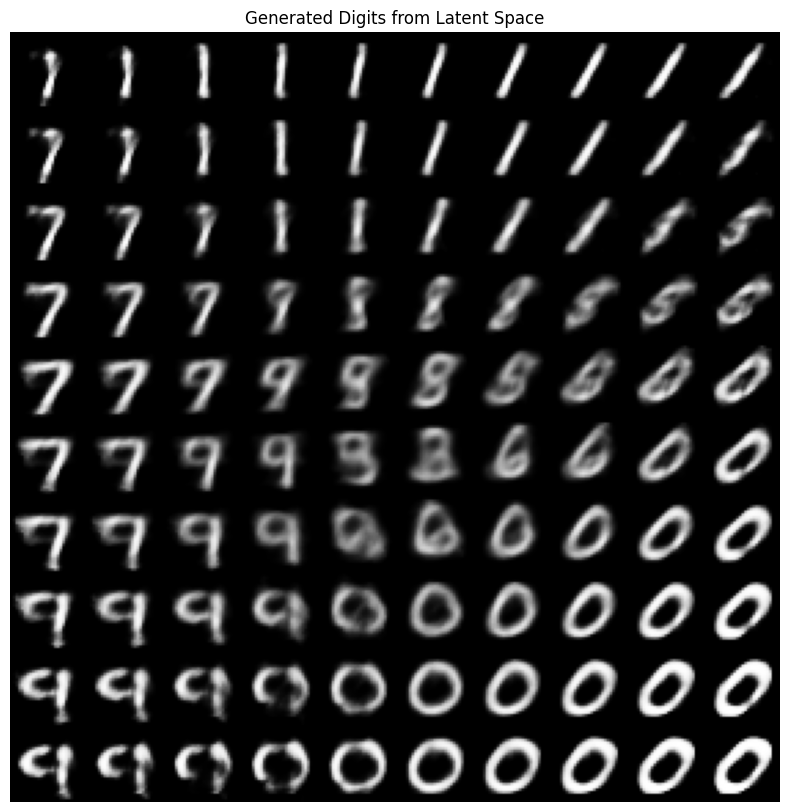

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, Model # Import Model here
from tensorflow.keras.datasets import mnist
from tensorflow.keras import backend as K
import tensorflow as tf

(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype("float32") / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))

latent_dim = 2

# Define Encoder
encoder_inputs = layers.Input(shape=(28, 28, 1))
x = layers.Flatten()(encoder_inputs)
x = layers.Dense(128, activation='relu')(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

# Define Sampling layer
def sampling(args):
    z_mean, z_log_var = args
    epsilon = K.random_normal(shape=(K.shape(z_mean)[0], latent_dim))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling, output_shape=(latent_dim,))([z_mean, z_log_var])
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")


# Define Decoder
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(128, activation='relu')(latent_inputs)
x = layers.Dense(784, activation='sigmoid')(x)
decoder_outputs = layers.Reshape((28, 28, 1))(x)
decoder = Model(latent_inputs, decoder_outputs, name="decoder")


# Define VAE Model as a subclass of tf.keras.Model
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def train_step(self, data):
        if isinstance(data, tuple):
            inputs, _ = data # Assuming autoencoder, input is target
        else:
            inputs = data

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(inputs)
            reconstruction = self.decoder(z)

            reconstruction_loss_value = tf.keras.losses.binary_crossentropy(layers.Flatten()(inputs), layers.Flatten()(reconstruction))
            reconstruction_loss_value *= 784 # Rescale to sum over pixels per image

            kl_loss_value = -0.5 * tf.keras.ops.sum(1 + z_log_var - tf.keras.ops.square(z_mean) - tf.keras.ops.exp(z_log_var), axis=-1)

            total_loss = tf.keras.ops.mean(reconstruction_loss_value + kl_loss_value) # Sum of the two loss components

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss_value)
        self.kl_loss_tracker.update_state(kl_loss_value)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# Instantiate the VAE model
vae = VAE(encoder, decoder)
vae.compile(optimizer='adam')
vae.fit(x_train, x_train, epochs=10, batch_size=64)


def plot_latent_space(decoder_model, n=10):
    digit_size = 28
    figure = np.zeros((digit_size * n, digit_size * n))
    grid_x = np.linspace(-4, 4, n)
    grid_y = np.linspace(-4, 4, n)

    for i, yi in enumerate(grid_x):
        for j, xi in enumerate(grid_y):
            z_sample = np.array([[xi, yi]])
            x_decoded = decoder_model.predict(z_sample)
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[i * digit_size: (i + 1) * digit_size, j * digit_size: (j + 1) * digit_size] = digit

    plt.figure(figsize=(10, 10))
    plt.imshow(figure, cmap='gray')
    plt.axis('off')
    plt.title("Generated Digits from Latent Space")
    plt.show()

plot_latent_space(decoder)